# Extract MS exposre meta

In [ ]:
from PIL import Image
import xml.etree.ElementTree as ET
import re
import pandas as pd

# Load image
img_path = '../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_005_AUTNorthshoreKaipatikiProject-KauriGlenMS/DJI_20250919113606_0001_MS_G.TIF'


img = Image.open(img_path)
img_exif = img.getexif()

# Find XML/XMP metadata (usually stored as bytes in one of the EXIF tags)
xml_bytes = None
for v in img_exif.values():
    if isinstance(v, bytes) and b"<x:xmpmeta" in v:
        xml_bytes = v
        break

if xml_bytes is None:
    raise ValueError("No XMP metadata found in EXIF.")

# Decode and clean XML
xml_str = xml_bytes.decode(errors="ignore")
xml_str = re.sub(r"(?s)^.*?<\?xpacket begin=.*?\?>", "", xml_str)
xml_str = re.sub(r"<\?xpacket end=.*$", "", xml_str).strip()

# Parse XML
root = ET.fromstring(xml_str)

# Extract all namespaced attributes and child text elements
data = {}

def collect_data(elem):
    # attributes
    for k, v in elem.attrib.items():
        data[k] = v
    # text
    if elem.text and elem.text.strip():
        data[elem.tag.split('}')[-1]] = elem.text.strip()
    # recurse
    for child in elem:
        collect_data(child)

collect_data(root)

# # Print all camera/drone data keys
# for k, v in sorted(data.items()):
#     if any(prefix in k for prefix in ["Camera", "drone-dji"]):
#         print(f"{k}: {v}")
        
# Filter and clean keys
filtered_data = {
    re.sub(r"^\{.*\}", "", k): v
    for k, v in data.items()
    if any(prefix in k for prefix in ["Camera", "drone-dji"])
}

# Create a DataFrame with one row
df = pd.DataFrame([filtered_data])

# Display the DataFrame
print(df)


  Version  ImageSource GpsStatus AltitudeType    GpsLatitude    GpsLongitude  \
0     1.6  MS_G_CAMERA       RTK       RtkAlt  -36.805713787  +174.740382445   

  AbsoluteAltitude RelativeAltitude GimbalRollDegree GimbalYawDegree  ...  \
0          +90.732          +46.564            +0.00          -81.10  ...   

  BandName      BandFreq Irradiance SensorGain ExposureTime  \
0    Green  560(+/-16)nm  21182.559      1.000         1530   

  SensorGainAdjustment SensorIndex BlackLevel               DroneID  \
0             0.512913           1       3200  1581F5FKD238100D5238   

  RigCameraIndex  
0              1  

[1 rows x 61 columns]


In [ ]:
from PIL import Image
import xml.etree.ElementTree as ET
import re
import pandas as pd

def extract_xmp_metadata(img_path):
    # Load image and get EXIF data
    img = Image.open(img_path)
    img_exif = img.getexif()

    # Find XML/XMP metadata
    xml_bytes = None
    for v in img_exif.values():
        if isinstance(v, bytes) and b"&lt;x:xmpmeta" in v:
            xml_bytes = v
            break

    if xml_bytes is None:
        return {}

    # Decode and clean XML
    xml_str = xml_bytes.decode(errors="ignore")
    xml_str = re.sub(r"(?s)^.*?&lt;\?xpacket begin=.*?\?&gt;", "", xml_str)
    xml_str = re.sub(r"&lt;\?xpacket end=.*$", "", xml_str).strip()

    # Parse XML
    try:
        root = ET.fromstring(xml_str)
    except ET.ParseError:
        return {}

    # Extract relevant data
    data = {}
    def collect_data(elem):
        for k, v in elem.attrib.items():
            data[k] = v
        if elem.text and elem.text.strip():
            data[elem.tag.split('}')[-1]] = elem.text.strip()
        for child in elem:
            collect_data(child)

    collect_data(root)

    # Filter for camera/drone related keys
    filtered_data = {k: v for k, v in data.items() if any(prefix in k for prefix in ["Camera", "drone-dji"])}
    return filtered_data



In [4]:
from utils.helper_functions import list_files

# List of image paths
image_paths = list_files(
    '../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_005_AUTNorthshoreKaipatikiProject-KauriGlenMS', ".TIF"
)

# Extract metadata for each image and compile into a DataFrame
metadata_list = []
for path in image_paths[1:5]:
    metadata = extract_xmp_metadata(path)
    metadata['image_path'] = path  # Include image path for reference
    metadata_list.append(metadata)

df = pd.DataFrame(metadata_list)
print(df)

                                          image_path
0  ../../3_0_data/full_extent/B_kauri_glen/A_raw/...
1  ../../3_0_data/full_extent/B_kauri_glen/A_raw/...
2  ../../3_0_data/full_extent/B_kauri_glen/A_raw/...
3  ../../3_0_data/full_extent/B_kauri_glen/A_raw/...


In [5]:
print(metadata)

{'image_path': '../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_005_AUTNorthshoreKaipatikiProject-KauriGlenMS/DJI_20250919113647_0021_MS_NIR.TIF'}


In [12]:
import os
from PIL import Image
import xml.etree.ElementTree as ET
import re
import pandas as pd

def extract_metadata_from_folder(folder_path):
    rows = []

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".tif"):
            img_path = os.path.join(folder_path, filename)
            print(img_path)
            try:
                img = Image.open(img_path)
                img_exif = img.getexif()

                # Find XML/XMP metadata
                xml_bytes = None
                for v in img_exif.values():
                    if isinstance(v, bytes) and b"&lt;x:xmpmeta" in v:
                        xml_bytes = v
                        break

                if xml_bytes is None:
                    continue  # Skip if no XMP metadata

                # Decode and clean XML
                xml_str = xml_bytes.decode(errors="ignore")
                xml_str = re.sub(r"(?s)^.*?&lt;\?xpacket begin=.*?\?&gt;", "", xml_str)
                xml_str = re.sub(r"&lt;\?xpacket end=.*$", "", xml_str).strip()

                # Parse XML
                root = ET.fromstring(xml_str)
                data = {}

                def collect_data(elem):
                    for k, v in elem.attrib.items():
                        data[k] = v
                    if elem.text and elem.text.strip():
                        data[elem.tag.split('}')[-1]] = elem.text.strip()
                    for child in elem:
                        collect_data(child)

                collect_data(root)

                # Filter and clean keys
                filtered_data = {
                    re.sub(r"^\{.*\}", "", k): v
                    for k, v in data.items()
                    if any(prefix in k for prefix in ["Camera", "drone-dji"])
                }

                # Add filename for traceability
                filtered_data["filename"] = filename

                rows.append(filtered_data)

            except Exception as e:
                print(f"Error processing {filename}: {e}")

    # Combine all rows into a DataFrame
    df = pd.DataFrame(rows)
    return df

In [13]:
folder = "../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_005_AUTNorthshoreKaipatikiProject-KauriGlenMS"
folder = "../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project"
df = extract_metadata_from_folder(folder)
print(df.head())

../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114226_0001_MS_G.TIF
../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114238_0002_MS_RE.TIF
../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114226_0001_MS_R.TIF
../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114238_0002_MS_NIR.TIF
../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114238_0002_MS_R.TIF
../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114226_0001_MS_NIR.TIF
../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_006_AUT-Northshore-Kaipatiki-Project/DJI_20250919114238_0002_MS_G.TIF
../../3_0_data/full_extent/B_kauri_glen/A_r

In [ ]:
from PIL import Image
import xml.etree.ElementTree as ET
import re
import pandas as pd

# Load image
def extract_xml(img_path):

    img = Image.open(img_path)
    img_exif = img.getexif()

    # Find XML/XMP metadata (usually stored as bytes in one of the EXIF tags)
    xml_bytes = None
    for v in img_exif.values():
        if isinstance(v, bytes) and b"<x:xmpmeta" in v:
            xml_bytes = v
            break

    if xml_bytes is None:
        raise ValueError("No XMP metadata found in EXIF.")

    # Decode and clean XML
    xml_str = xml_bytes.decode(errors="ignore")
    xml_str = re.sub(r"(?s)^.*?<\?xpacket begin=.*?\?>", "", xml_str)
    xml_str = re.sub(r"<\?xpacket end=.*$", "", xml_str).strip()

    # Parse XML
    root = ET.fromstring(xml_str)

    # Extract all namespaced attributes and child text elements
    data = {}

    def collect_data(elem):
        # attributes
        for k, v in elem.attrib.items():
            data[k] = v
        # text
        if elem.text and elem.text.strip():
            data[elem.tag.split('}')[-1]] = elem.text.strip()
        # recurse
        for child in elem:
            collect_data(child)

    collect_data(root)

    # # Print all camera/drone data keys
    # for k, v in sorted(data.items()):
    #     if any(prefix in k for prefix in ["Camera", "drone-dji"]):
    #         print(f"{k}: {v}")
            
    # Filter and clean keys
    filtered_data = {
        re.sub(r"^\{.*\}", "", k): v
        for k, v in data.items()
        if any(prefix in k for prefix in ["Camera", "drone-dji"])
    }

    # Create a DataFrame with one row
    df = pd.DataFrame([filtered_data])

    # Display the DataFrame
    return df


In [ ]:
import os
import re

image_paths = list_files(
    '../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_005_AUTNorthshoreKaipatikiProject-KauriGlenMS', ".TIF"
)

img_meta = pd.DataFrame()

for img_path in image_paths:
    df = extract_xml(img_path)

    # Extract image ID from filename
    basename = os.path.basename(img_path)
    match = re.search(r"(\d{14}_\d{4})", basename)
    img_id = match.group(1) if match else None

    df["img_id"] = img_id
    img_meta = pd.concat([img_meta, df], ignore_index=True)
    
img_meta.to_csv("../../3_0_data/full_extent/B_kauri_glen/A_raw/ms/DJI_202509191134_005_AUTNorthshoreKaipatikiProject-KauriGlenMS/metadata.csv", index=False)
    

In [38]:
img_meta

,Version,ImageSource,GpsStatus,AltitudeType,GpsLatitude,GpsLongitude,AbsoluteAltitude,RelativeAltitude,GimbalRollDegree,GimbalYawDegree,...,BandFreq,Irradiance,SensorGain,ExposureTime,SensorGainAdjustment,SensorIndex,BlackLevel,DroneID,RigCameraIndex,img_id
0,1.6,MS_R_CAMERA,RTK,RtkAlt,-36.805535335,+174.739759109,+94.530,+50.370,+0.00,+97.90,...,650(+/-16)nm,18121.521,1.575,1953,0.571341,2,3200,1581F5FKD238100D5238,2,20250919113806_0060
1,1.6,MS_RE_CAMERA,RTK,RtkAlt,-36.805521950,+174.737753203,+97.637,+53.462,+0.00,+86.10,...,730(+/-16)nm,14500.918,1.874,1953,0.759301,3,3200,1581F5FKD238100D5238,3,20250919114103_0143
2,1.6,MS_R_CAMERA,RTK,RtkAlt,-36.805506692,+174.737572545,+98.828,+54.670,+0.00,+97.90,...,650(+/-16)nm,17455.672,2.265,1953,0.571341,2,3200,1581F5FKD238100D5238,2,20250919113940_0106
3,1.6,MS_G_CAMERA,RTK,RtkAlt,-36.805250804,+174.738186253,+105.269,+61.097,+0.00,-82.70,...,560(+/-16)nm,20727.326,1.853,1953,0.512913,1,3200,1581F5FKD238100D5238,1,20250919113906_0089
4,1.6,MS_NIR_CAMERA,RTK,RtkAlt,-36.805494196,+174.738438156,+96.133,+51.993,+0.00,-82.70,...,860(+/-26)nm,14208.620,1.000,1724,0.917817,4,3200,1581F5FKD238100D5238,4,20250919113647_0021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,1.6,MS_RE_CAMERA,RTK,RtkAlt,-36.805646080,+174.737846818,+97.877,+53.723,+180.00,+97.60,...,730(+/-16)nm,14893.951,1.654,1953,0.759301,3,3200,1581F5FKD238100D5238,3,20250919114023_0127
604,1.6,MS_G_CAMERA,RTK,RtkAlt,-36.805474898,+174.740184993,+94.203,+50.059,+0.00,-81.80,...,560(+/-16)nm,21660.953,1.967,1953,0.512913,1,3200,1581F5FKD238100D5238,1,20250919113825_0069
605,1.6,MS_G_CAMERA,RTK,RtkAlt,-36.805272510,+174.738386391,+103.696,+59.529,+0.00,-82.60,...,560(+/-16)nm,20649.338,2.181,1953,0.512913,1,3200,1581F5FKD238100D5238,1,20250919113901_0087
606,1.6,MS_R_CAMERA,RTK,RtkAlt,-36.805493236,+174.738253983,+93.612,+49.397,+0.00,+86.00,...,650(+/-16)nm,17789.016,2.636,1953,0.571341,2,3200,1581F5FKD238100D5238,2,20250919114113_0148


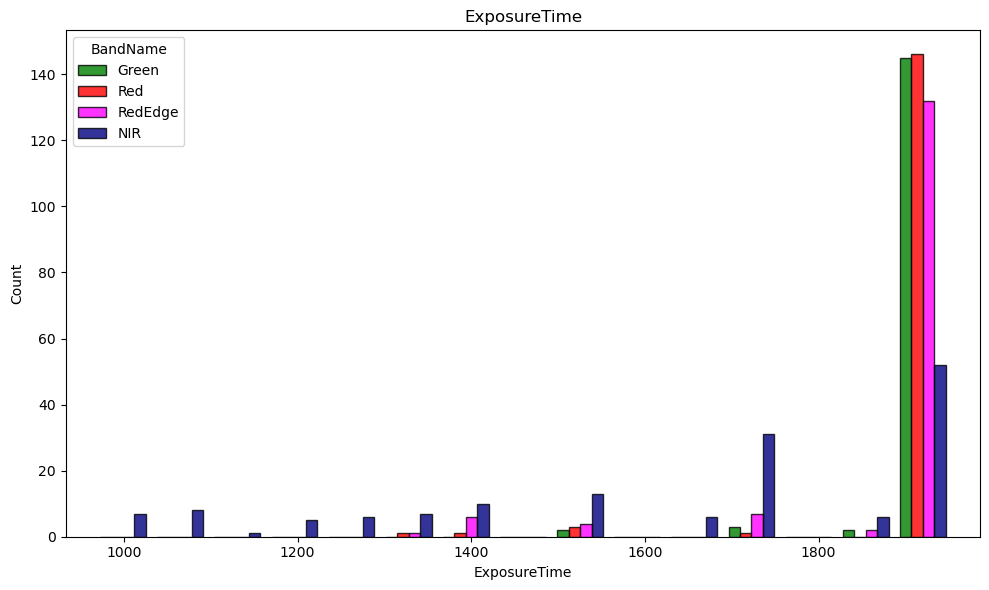

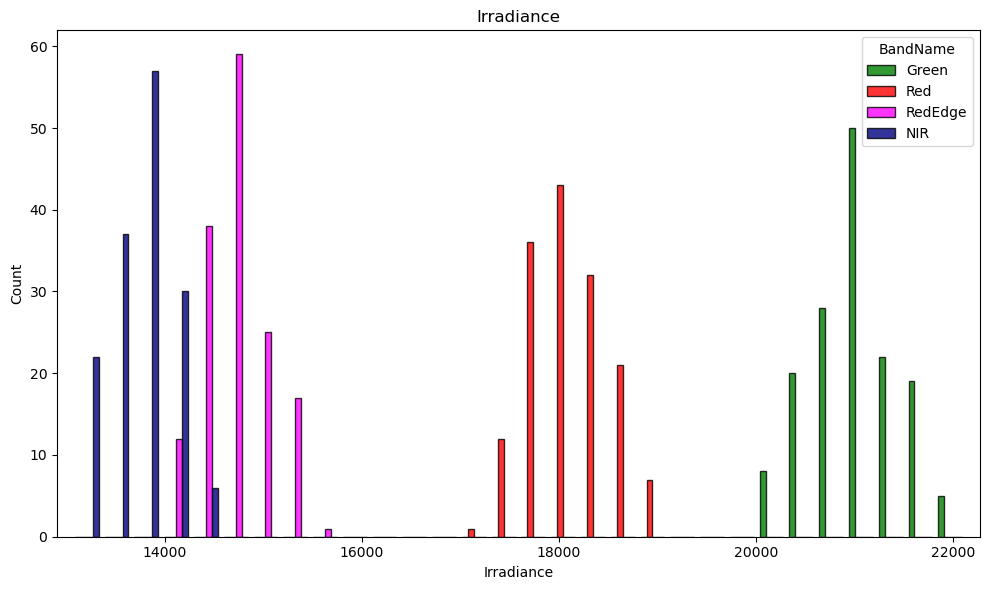

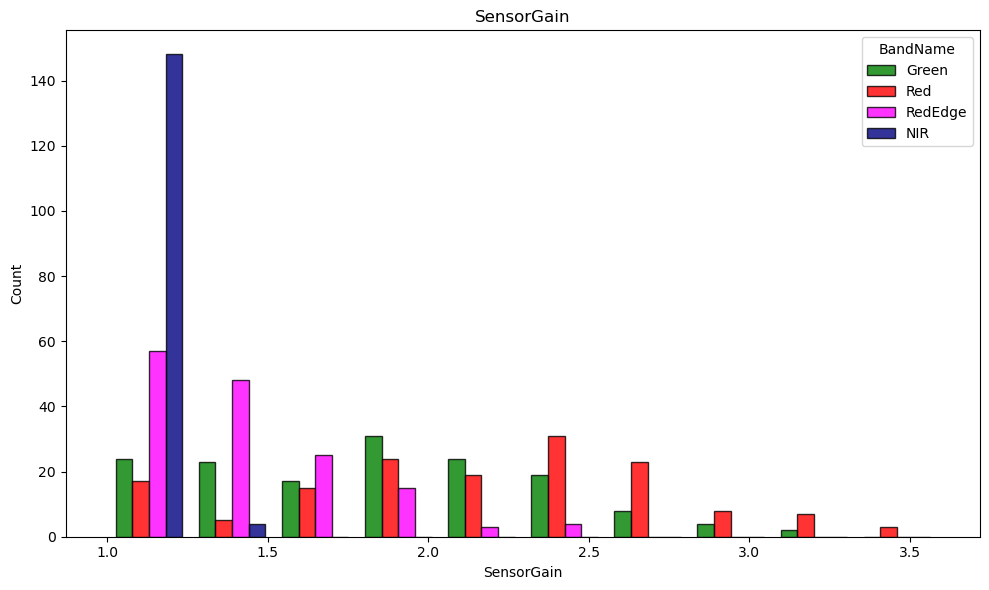

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure numeric conversion
for col in ['ExposureTime', 'Irradiance', 'SensorGain']:
    img_meta[col] = pd.to_numeric(img_meta[col], errors='coerce')

# Group by 'img_id' and compute summary statistics
summary_stats = img_meta.groupby('img_id')[['ExposureTime', 'Irradiance', 'SensorGain']].agg(['mean', 'std', 'min', 'max', 'count'])


bands = ['Green', 'Red', 'RedEdge', 'NIR']
colors = {'Red': 'red', 'RedEdge': 'magenta', 'Green': 'green', 'NIR': 'navy'}

# explicit mapping to avoid zip-order confusion
bins_per_col = {'ExposureTime': 15, 'Irradiance': 30, 'SensorGain': 10}
cols = ['ExposureTime', 'Irradiance', 'SensorGain']

for col in cols:
    n_bins = bins_per_col[col]
    # combined range across bands -> shared bins
    combined = img_meta.loc[img_meta['BandName'].isin(bands), col].dropna()
    if combined.empty:
        continue

    min_v, max_v = combined.min(), combined.max()
    if min_v == max_v:
        min_v -= 0.5
        max_v += 0.5

    bin_edges = np.linspace(min_v, max_v, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0
    bin_width = bin_edges[1] - bin_edges[0]
    # divide bin width among bands and center groups
    n_bands = len(bands)
    bar_width = bin_width / (n_bands + 1)
    offsets = (np.arange(n_bands) - (n_bands - 1) / 2.0) * bar_width

    plt.figure(figsize=(10, 6))
    for i, band in enumerate(bands):
        data = img_meta.loc[img_meta['BandName'] == band, col].dropna()
        if data.empty:
            continue
        counts, _ = np.histogram(data, bins=bin_edges)
        plt.bar(bin_centers + offsets[i], counts, width=bar_width,
                align='center', color=colors.get(band), edgecolor='black', label=band, alpha=0.8)

    plt.xlim(min_v - 0.5 * bin_width, max_v + 0.5 * bin_width)
    plt.title(f"{col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="BandName")
    plt.tight_layout()
    plt.show()


In [35]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(img_meta, geometry=gpd.points_from_xy(img_meta['GpsLongitude'], img_meta['GpsLatitude']))

In [ ]:
for i, group in gdf.groupby('ImageSource'):
    print(i)
    print(group)

In [ ]:
for camperagdf.groupby('ImageSource')

,Version,ImageSource,GpsStatus,AltitudeType,GpsLatitude,GpsLongitude,AbsoluteAltitude,RelativeAltitude,GimbalRollDegree,GimbalYawDegree,...,BandFreq,Irradiance,SensorGain,ExposureTime,SensorGainAdjustment,SensorIndex,BlackLevel,DroneID,RigCameraIndex,geometry
0,1.6,MS_R_CAMERA,RTK,RtkAlt,-36.805535335,+174.739759109,+94.530,+50.370,+0.00,+97.90,...,650(+/-16)nm,18121.521,1.575,1953,0.571341,2,3200,1581F5FKD238100D5238,2,POINT (174.73976 -36.80554)
1,1.6,MS_RE_CAMERA,RTK,RtkAlt,-36.805521950,+174.737753203,+97.637,+53.462,+0.00,+86.10,...,730(+/-16)nm,14500.918,1.874,1953,0.759301,3,3200,1581F5FKD238100D5238,3,POINT (174.73775 -36.80552)
2,1.6,MS_R_CAMERA,RTK,RtkAlt,-36.805506692,+174.737572545,+98.828,+54.670,+0.00,+97.90,...,650(+/-16)nm,17455.672,2.265,1953,0.571341,2,3200,1581F5FKD238100D5238,2,POINT (174.73757 -36.80551)
3,1.6,MS_G_CAMERA,RTK,RtkAlt,-36.805250804,+174.738186253,+105.269,+61.097,+0.00,-82.70,...,560(+/-16)nm,20727.326,1.853,1953,0.512913,1,3200,1581F5FKD238100D5238,1,POINT (174.73819 -36.80525)
4,1.6,MS_NIR_CAMERA,RTK,RtkAlt,-36.805494196,+174.738438156,+96.133,+51.993,+0.00,-82.70,...,860(+/-26)nm,14208.620,1.000,1724,0.917817,4,3200,1581F5FKD238100D5238,4,POINT (174.73844 -36.80549)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,1.6,MS_RE_CAMERA,RTK,RtkAlt,-36.805646080,+174.737846818,+97.877,+53.723,+180.00,+97.60,...,730(+/-16)nm,14893.951,1.654,1953,0.759301,3,3200,1581F5FKD238100D5238,3,POINT (174.73785 -36.80565)
604,1.6,MS_G_CAMERA,RTK,RtkAlt,-36.805474898,+174.740184993,+94.203,+50.059,+0.00,-81.80,...,560(+/-16)nm,21660.953,1.967,1953,0.512913,1,3200,1581F5FKD238100D5238,1,POINT (174.74018 -36.80547)
605,1.6,MS_G_CAMERA,RTK,RtkAlt,-36.805272510,+174.738386391,+103.696,+59.529,+0.00,-82.60,...,560(+/-16)nm,20649.338,2.181,1953,0.512913,1,3200,1581F5FKD238100D5238,1,POINT (174.73839 -36.80527)
606,1.6,MS_R_CAMERA,RTK,RtkAlt,-36.805493236,+174.738253983,+93.612,+49.397,+0.00,+86.00,...,650(+/-16)nm,17789.016,2.636,1953,0.571341,2,3200,1581F5FKD238100D5238,2,POINT (174.73825 -36.80549)


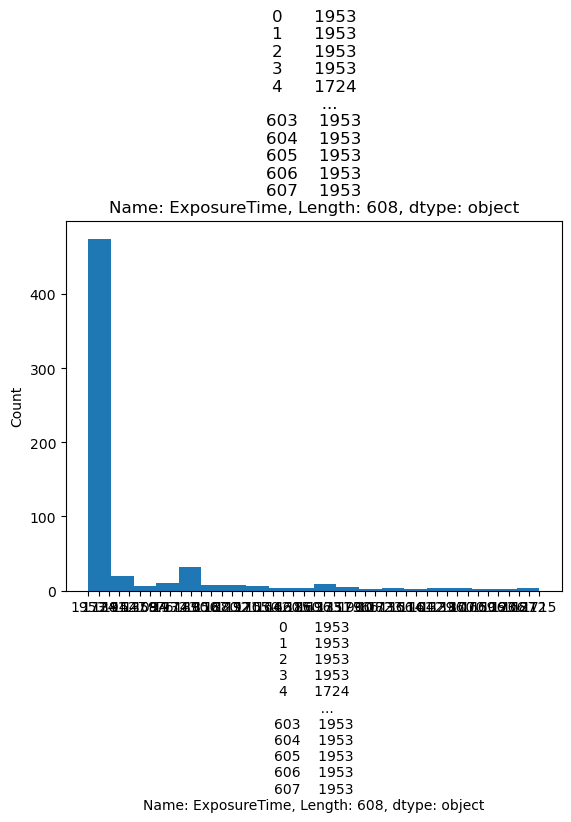

In [33]:
import matplotlib.pyplot as plt

# Plot histograms
f=img_meta.ExposureTime
    
plt.figure()
plt.hist(f, bins=20)
plt.title(f)
plt.xlabel(f)
plt.ylabel("Count")
plt.show()